# Demo: Robust EM Algorithm for Pose Estimation

This notebook demonstrates the complete workflow for fitting a **Robust Gaussian Mixture Model** to heatmap samples for human pose estimation.

## Mathematical Foundation

We model the keypoint location distribution as:

$$P(\vec{x} | \theta) = \sum_{k=1}^{K} \pi_k \mathcal{N}(\vec{x} | \vec{\mu}_k, \Sigma_k) + \pi_u \cdot U(\vec{x} | A)$$

Where:
- $\pi_k$: Mixing weights for Gaussian components
- $\vec{\mu}_k$: Component means (keypoint locations)
- $\Sigma_k$: Covariance matrices (uncertainty ellipses)
- $\pi_u$: Weight for uniform component (outlier absorption)
- $A$: Bounding area for uniform distribution

## Workflow

1. **Generate/Load Heatmap** → Sample from a synthetic or real heatmap
2. **Outer Loop Strategy** → Bootstrap resampling for stability
3. **Model Selection** → AIC/BIC to choose unimodal vs bimodal
4. **Aggregation** → Combine results across iterations
5. **Visualization** → Plot confidence ellipses

In [1]:
# =============================================================================
# Cell 1: Imports and Setup
# =============================================================================
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy import stats
from sklearn.datasets import make_blobs

# Our custom modules
from pose_uncertainty.core.mixture import (
    RobustGaussianMixture,
    MixtureResult,
    select_best_model,
    fit_with_outer_loop,
)

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

# Reproducibility
np.random.seed(42)

print("✓ Imports successful!")

✓ Imports successful!


## 1. Generate Synthetic Heatmap Data

We'll create synthetic heatmaps representing:
- **Unimodal**: Single confident keypoint (e.g., nose)
- **Bimodal**: Ambiguous keypoint (e.g., left/right elbow swap)

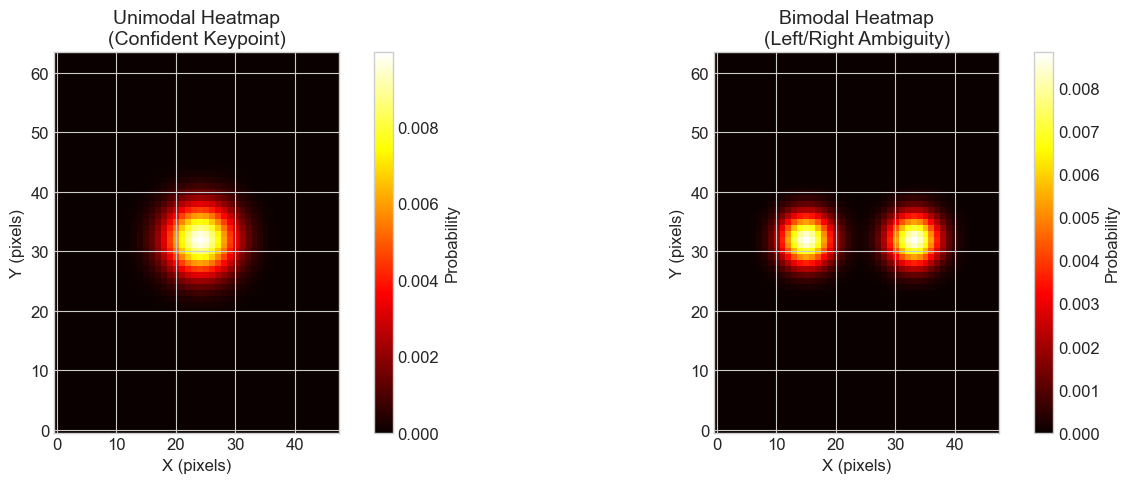

Heatmap shapes: (64, 48) (64, 48)


In [2]:
# =============================================================================
# Cell 2: Create Synthetic Heatmaps
# =============================================================================

def create_gaussian_heatmap(
    height: int = 64,
    width: int = 48,
    centers: list = None,
    sigmas: list = None,
    weights: list = None
) -> np.ndarray:
    """
    Create a synthetic heatmap from Gaussian mixtures.
    
    Args:
        height, width: Heatmap dimensions
        centers: List of (x, y) center coordinates
        sigmas: List of standard deviations
        weights: List of mixing weights
    
    Returns:
        Normalized heatmap of shape (height, width)
    """
    if centers is None:
        centers = [(24, 32)]  # Default: single centered peak
    if sigmas is None:
        sigmas = [4.0] * len(centers)
    if weights is None:
        weights = [1.0] * len(centers)
    
    y, x = np.ogrid[0:height, 0:width]
    heatmap = np.zeros((height, width), dtype=np.float32)
    
    for (cx, cy), sigma, w in zip(centers, sigmas, weights):
        gaussian = np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * sigma**2))
        heatmap += w * gaussian
    
    # Normalize to probability distribution
    heatmap /= heatmap.sum()
    return heatmap


def sample_from_heatmap(heatmap: np.ndarray, n_samples: int = 1000, seed: int = 42) -> np.ndarray:
    """
    Draw samples from a heatmap using inverse CDF sampling.
    
    Args:
        heatmap: 2D probability distribution
        n_samples: Number of samples to draw
        seed: Random seed
    
    Returns:
        Array of shape (n_samples, 2) with (x, y) coordinates
    """
    rng = np.random.default_rng(seed)
    
    # Flatten and normalize
    flat = heatmap.flatten()
    flat = flat / flat.sum()
    
    # Sample indices
    indices = rng.choice(len(flat), size=n_samples, p=flat)
    
    # Convert to (x, y) coordinates
    height, width = heatmap.shape
    y_coords = indices // width
    x_coords = indices % width
    
    # Add sub-pixel jitter for continuous distribution
    jitter = rng.uniform(-0.5, 0.5, size=(n_samples, 2))
    samples = np.column_stack([x_coords, y_coords]) + jitter
    
    return samples.astype(np.float64)


# Create unimodal heatmap (confident keypoint)
heatmap_unimodal = create_gaussian_heatmap(
    centers=[(24, 32)],
    sigmas=[4.0],
    weights=[1.0]
)

# Create bimodal heatmap (ambiguous keypoint - left/right swap)
heatmap_bimodal = create_gaussian_heatmap(
    centers=[(15, 32), (33, 32)],
    sigmas=[3.0, 3.0],
    weights=[0.5, 0.5]
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(heatmap_unimodal, cmap='hot', origin='lower')
axes[0].set_title('Unimodal Heatmap\n(Confident Keypoint)', fontsize=14)
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')
plt.colorbar(im1, ax=axes[0], label='Probability')

im2 = axes[1].imshow(heatmap_bimodal, cmap='hot', origin='lower')
axes[1].set_title('Bimodal Heatmap\n(Left/Right Ambiguity)', fontsize=14)
axes[1].set_xlabel('X (pixels)')
axes[1].set_ylabel('Y (pixels)')
plt.colorbar(im2, ax=axes[1], label='Probability')

plt.tight_layout()
plt.show()

print("Heatmap shapes:", heatmap_unimodal.shape, heatmap_bimodal.shape)

## 2. Sample from Heatmaps and Fit GMM

We'll demonstrate the EM algorithm on both unimodal and bimodal cases.

In [3]:
# =============================================================================
# Cell 3: Sample and Fit Basic GMM
# =============================================================================

# Sample from both heatmaps
N_SAMPLES = 1000

samples_unimodal = sample_from_heatmap(heatmap_unimodal, n_samples=N_SAMPLES, seed=42)
samples_bimodal = sample_from_heatmap(heatmap_bimodal, n_samples=N_SAMPLES, seed=42)

print(f"Unimodal samples shape: {samples_unimodal.shape}")
print(f"Bimodal samples shape: {samples_bimodal.shape}")

# Fit GMM to unimodal data
gmm_uni = RobustGaussianMixture(
    n_components=1,
    reg_covar=1e-4,
    max_iter=100,
    tol=1e-4,
    random_state=42
)
gmm_uni.fit(samples_unimodal)

# Fit GMM to bimodal data
gmm_bi = RobustGaussianMixture(
    n_components=2,
    reg_covar=1e-4,
    max_iter=100,
    tol=1e-4,
    random_state=42
)
gmm_bi.fit(samples_bimodal)

# Print results
print("\n" + "="*60)
print("UNIMODAL GMM RESULTS:")
print("="*60)
print(f"  Converged: {gmm_uni.converged_}")
print(f"  Iterations: {gmm_uni.n_iter_}")
print(f"  Log-likelihood: {gmm_uni.log_likelihood_:.2f}")
mean_uni, cov_uni = gmm_uni.get_mode()
print(f"  Estimated mean: ({mean_uni[0]:.2f}, {mean_uni[1]:.2f})")
print(f"  Uniform weight: {gmm_uni.uniform_weight_:.4f}")

print("\n" + "="*60)
print("BIMODAL GMM RESULTS:")
print("="*60)
print(f"  Converged: {gmm_bi.converged_}")
print(f"  Iterations: {gmm_bi.n_iter_}")
print(f"  Log-likelihood: {gmm_bi.log_likelihood_:.2f}")
for i, comp in enumerate(gmm_bi.components_):
    print(f"  Component {i+1}: mean=({comp.mean[0]:.2f}, {comp.mean[1]:.2f}), weight={comp.weight:.3f}")
print(f"  Uniform weight: {gmm_bi.uniform_weight_:.4f}")

Unimodal samples shape: (1000, 2)
Bimodal samples shape: (1000, 2)

UNIMODAL GMM RESULTS:
  Converged: True
  Iterations: 23
  Log-likelihood: -5573.63
  Estimated mean: (23.81, 31.97)
  Uniform weight: 0.0147

BIMODAL GMM RESULTS:
  Converged: True
  Iterations: 55
  Log-likelihood: -5717.56
  Component 1: mean=(32.88, 32.04), weight=0.515
  Component 2: mean=(14.92, 31.89), weight=0.485
  Uniform weight: 0.0000


## 3. Model Selection with AIC/BIC

Automatically determine if the data is unimodal or bimodal using information criteria:

$$\text{Score} = w_{AIC} \cdot AIC + w_{BIC} \cdot BIC$$

Where:
- $AIC = 2k - 2\ln(L)$
- $BIC = k\ln(n) - 2\ln(L)$

In [4]:
# =============================================================================
# Cell 4: Model Selection
# =============================================================================

# Select best model for unimodal data
result_uni = select_best_model(
    samples_unimodal,
    aic_weight=0.5,
    bic_weight=0.5,
    reg_covar=1e-4,
    random_state=42
)

# Select best model for bimodal data
result_bi = select_best_model(
    samples_bimodal,
    aic_weight=0.5,
    bic_weight=0.5,
    reg_covar=1e-4,
    random_state=42
)

print("="*60)
print("MODEL SELECTION RESULTS")
print("="*60)

print("\n📊 Unimodal Data:")
print(f"  Selected model: {result_uni.model_type.upper()}")
print(f"  AIC: {result_uni.aic:.2f}")
print(f"  BIC: {result_uni.bic:.2f}")
print(f"  Best mean: ({result_uni.best_mean[0]:.2f}, {result_uni.best_mean[1]:.2f})")

print("\n📊 Bimodal Data:")
print(f"  Selected model: {result_bi.model_type.upper()}")
print(f"  AIC: {result_bi.aic:.2f}")
print(f"  BIC: {result_bi.bic:.2f}")
print(f"  Best mean: ({result_bi.best_mean[0]:.2f}, {result_bi.best_mean[1]:.2f})")

# Verify model selection is correct
print("\n" + "="*60)
print("✓ Model selection correct:" if result_uni.model_type == 'unimodal' and result_bi.model_type == 'bimodal' 
      else "✗ Model selection incorrect!")

EM did not converge after 100 iterations


MODEL SELECTION RESULTS

📊 Unimodal Data:
  Selected model: UNIMODAL
  AIC: 11159.25
  BIC: 11188.70
  Best mean: (23.81, 31.97)

📊 Bimodal Data:
  Selected model: BIMODAL
  AIC: 11459.12
  BIC: 11518.02
  Best mean: (32.88, 32.04)

✓ Model selection correct:


## 4. Outer Loop Strategy (Bootstrap Stability)

For more robust estimates, we use a bootstrap resampling strategy:

```
For t = 1 to T:
    1. Bootstrap resample from original data
    2. Fit Model A (bimodal) vs Model B (unimodal)
    3. Select winner via AIC/BIC
    4. Store winning prediction

Aggregate: mean of winning predictions
```

In [5]:
# =============================================================================
# Cell 5: Outer Loop Strategy
# =============================================================================

# Configuration (matching config.yaml)
CONFIG = {
    'n_outer_iterations': 10,    # T: Number of bootstrap iterations
    'n_resamples': 500,          # Samples per bootstrap
    'aic_weight': 0.5,
    'bic_weight': 0.5,
    'reg_covar': 1e-4,
    'max_iter': 100,
    'tol': 1e-4,
}

print("Running outer loop strategy...")
print(f"  Bootstrap iterations: {CONFIG['n_outer_iterations']}")
print(f"  Samples per iteration: {CONFIG['n_resamples']}")

# Fit with outer loop for bimodal data
result_outer = fit_with_outer_loop(
    samples_bimodal,
    n_outer_iterations=CONFIG['n_outer_iterations'],
    n_resamples=CONFIG['n_resamples'],
    aic_weight=CONFIG['aic_weight'],
    bic_weight=CONFIG['bic_weight'],
    reg_covar=CONFIG['reg_covar'],
    max_iter=CONFIG['max_iter'],
    tol=CONFIG['tol'],
    random_state=42
)

print("\n" + "="*60)
print("OUTER LOOP RESULTS (Bimodal Data)")
print("="*60)
print(f"  Dominant model type: {result_outer.model_type.upper()}")
print(f"  Aggregated mean: ({result_outer.best_mean[0]:.2f}, {result_outer.best_mean[1]:.2f})")
print(f"  Total iterations: {result_outer.n_iterations}")
print(f"  All converged: {result_outer.converged}")

# Show covariance (uncertainty)
print(f"\n  Aggregated covariance:")
print(f"    σ²_x = {result_outer.best_covariance[0, 0]:.4f}")
print(f"    σ²_y = {result_outer.best_covariance[1, 1]:.4f}")
print(f"    σ_xy = {result_outer.best_covariance[0, 1]:.4f}")

Running outer loop strategy...
  Bootstrap iterations: 10
  Samples per iteration: 500


EM did not converge after 100 iterations
EM did not converge after 100 iterations
EM did not converge after 100 iterations



OUTER LOOP RESULTS (Bimodal Data)
  Dominant model type: BIMODAL
  Aggregated mean: (31.15, 31.97)
  Total iterations: 704
  All converged: False

  Aggregated covariance:
    σ²_x = 39.3189
    σ²_y = 9.9024
    σ_xy = 0.5324


## 5. Visualization: Confidence Ellipses

Visualize the fitted mixture model with:
- Data points (samples)
- Component means
- 95% confidence ellipses from covariance matrices

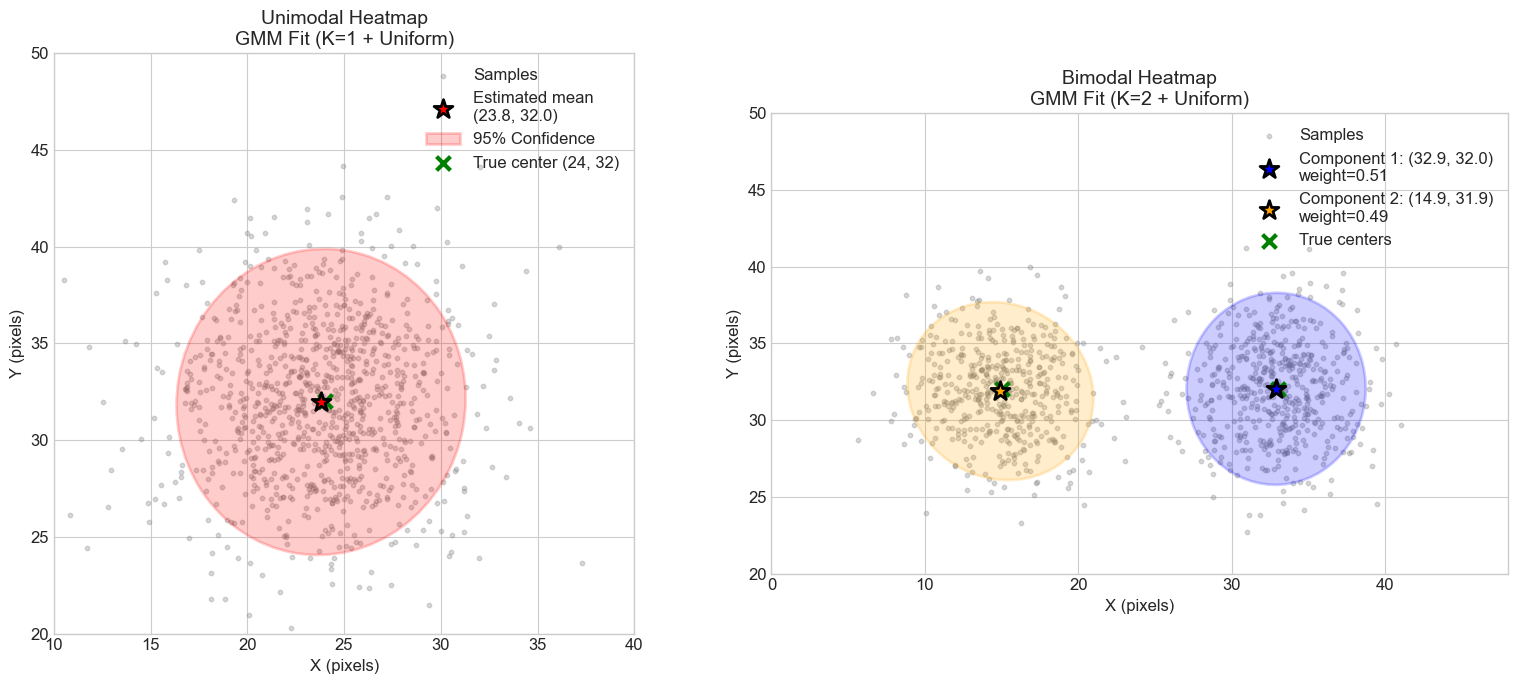

In [6]:
# =============================================================================
# Cell 6: Visualization with Confidence Ellipses
# =============================================================================

def plot_confidence_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """
    Plot a covariance confidence ellipse.
    
    Args:
        ax: Matplotlib axes
        mean: (x, y) center
        cov: 2x2 covariance matrix
        n_std: Number of standard deviations (2 ≈ 95% CI)
        **kwargs: Passed to Ellipse patch
    """
    # Eigendecomposition for ellipse parameters
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # Sort by eigenvalue (descending)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    # Ellipse angle (in degrees)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    
    # Ellipse width and height (2 * n_std * sqrt(eigenvalue))
    width = 2 * n_std * np.sqrt(eigenvalues[0])
    height = 2 * n_std * np.sqrt(eigenvalues[1])
    
    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        **kwargs
    )
    ax.add_patch(ellipse)
    return ellipse


# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# =========================
# Plot 1: Unimodal Result
# =========================
ax1 = axes[0]
ax1.set_title('Unimodal Heatmap\nGMM Fit (K=1 + Uniform)', fontsize=14)

# Plot samples
ax1.scatter(samples_unimodal[:, 0], samples_unimodal[:, 1], 
            alpha=0.3, s=10, c='gray', label='Samples')

# Plot fitted mean
mean_uni, cov_uni = gmm_uni.get_mode()
ax1.scatter(mean_uni[0], mean_uni[1], 
            s=200, c='red', marker='*', edgecolor='black', linewidth=2,
            label=f'Estimated mean\n({mean_uni[0]:.1f}, {mean_uni[1]:.1f})', zorder=5)

# Plot confidence ellipse (95% CI = 2σ)
plot_confidence_ellipse(ax1, mean_uni, cov_uni, n_std=2.0,
                       facecolor='red', alpha=0.2, edgecolor='red', linewidth=2,
                       label='95% Confidence')

# True center marker
ax1.scatter(24, 32, s=100, c='green', marker='x', linewidth=3,
            label='True center (24, 32)')

ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax1.legend(loc='upper right')
ax1.set_xlim(10, 40)
ax1.set_ylim(20, 50)
ax1.set_aspect('equal')

# =========================
# Plot 2: Bimodal Result
# =========================
ax2 = axes[1]
ax2.set_title('Bimodal Heatmap\nGMM Fit (K=2 + Uniform)', fontsize=14)

# Plot samples
ax2.scatter(samples_bimodal[:, 0], samples_bimodal[:, 1], 
            alpha=0.3, s=10, c='gray', label='Samples')

# Plot fitted components
colors = ['blue', 'orange']
for i, comp in enumerate(gmm_bi.components_):
    # Mean marker
    ax2.scatter(comp.mean[0], comp.mean[1], 
                s=200, c=colors[i], marker='*', edgecolor='black', linewidth=2,
                label=f'Component {i+1}: ({comp.mean[0]:.1f}, {comp.mean[1]:.1f})\nweight={comp.weight:.2f}',
                zorder=5)
    
    # Confidence ellipse
    plot_confidence_ellipse(ax2, comp.mean, comp.covariance, n_std=2.0,
                           facecolor=colors[i], alpha=0.2, edgecolor=colors[i], linewidth=2)

# True centers
ax2.scatter([15, 33], [32, 32], s=100, c='green', marker='x', linewidth=3,
            label='True centers')

ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')
ax2.legend(loc='upper right')
ax2.set_xlim(0, 48)
ax2.set_ylim(20, 50)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()


## 6. Outlier Robustness Demo

Demonstrate how the uniform component absorbs spatial noise and outliers without biasing the Gaussian components.

Total samples: 1150 (including 150 outliers)

OUTLIER ROBUSTNESS TEST
Without outliers:
  Mean: (23.81, 31.97)
  Uniform weight: 0.0147

With 15% outliers:
  Mean: (23.81, 31.93)
  Uniform weight: 0.1339

  Mean shift: 0.043 pixels
  Uniform weight increased: True


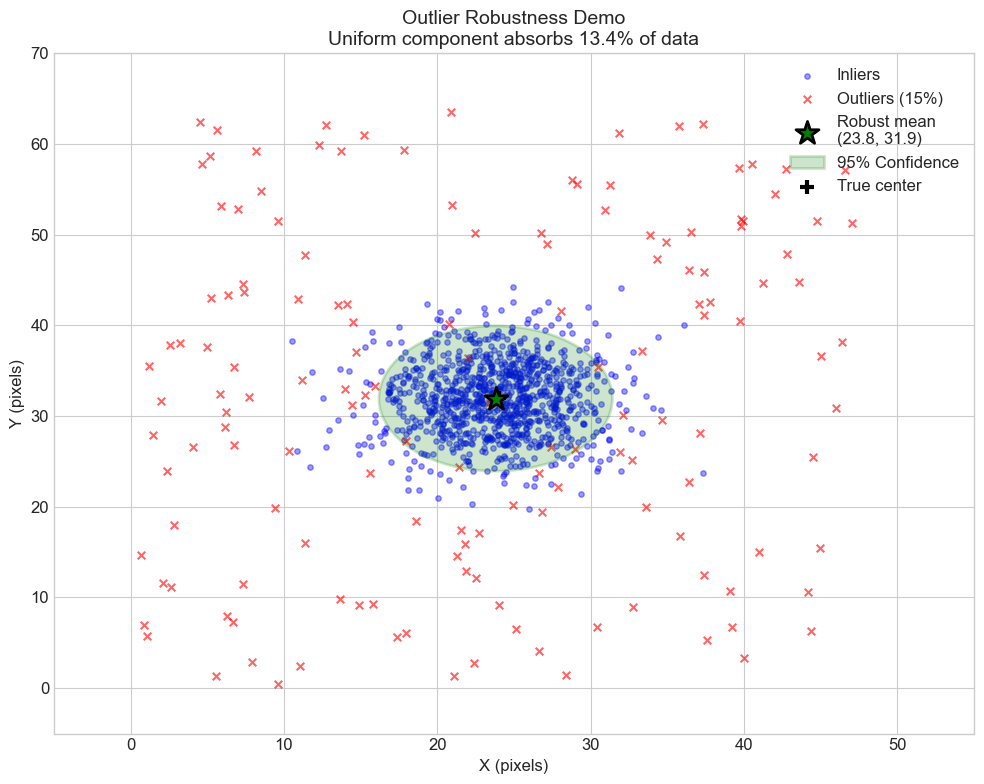

In [7]:
# =============================================================================
# Cell 7: Outlier Robustness
# =============================================================================

# Add 15% outliers to the unimodal data
rng = np.random.default_rng(42)
n_outliers = int(0.15 * len(samples_unimodal))
outliers = rng.uniform(
    low=[0, 0],
    high=[48, 64],
    size=(n_outliers, 2)
)

samples_with_outliers = np.vstack([samples_unimodal, outliers])
print(f"Total samples: {len(samples_with_outliers)} (including {n_outliers} outliers)")

# Fit GMM with outliers
gmm_outliers = RobustGaussianMixture(
    n_components=1,
    reg_covar=1e-4,
    random_state=42
)
gmm_outliers.fit(samples_with_outliers, initial_uniform_weight=0.05)

mean_outliers, cov_outliers = gmm_outliers.get_mode()

print("\n" + "="*60)
print("OUTLIER ROBUSTNESS TEST")
print("="*60)
print(f"Without outliers:")
print(f"  Mean: ({mean_uni[0]:.2f}, {mean_uni[1]:.2f})")
print(f"  Uniform weight: {gmm_uni.uniform_weight_:.4f}")

print(f"\nWith 15% outliers:")
print(f"  Mean: ({mean_outliers[0]:.2f}, {mean_outliers[1]:.2f})")
print(f"  Uniform weight: {gmm_outliers.uniform_weight_:.4f}")

print(f"\n  Mean shift: {np.linalg.norm(mean_outliers - mean_uni):.3f} pixels")
print(f"  Uniform weight increased: {gmm_outliers.uniform_weight_ > gmm_uni.uniform_weight_}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))

# Plot inliers
ax.scatter(samples_unimodal[:, 0], samples_unimodal[:, 1], 
           alpha=0.4, s=15, c='blue', label='Inliers')

# Plot outliers
ax.scatter(outliers[:, 0], outliers[:, 1], 
           alpha=0.6, s=30, c='red', marker='x', label='Outliers (15%)')

# Plot fitted mean
ax.scatter(mean_outliers[0], mean_outliers[1], 
           s=300, c='green', marker='*', edgecolor='black', linewidth=2,
           label=f'Robust mean\n({mean_outliers[0]:.1f}, {mean_outliers[1]:.1f})', zorder=5)

# Confidence ellipse
plot_confidence_ellipse(ax, mean_outliers, cov_outliers, n_std=2.0,
                       facecolor='green', alpha=0.2, edgecolor='green', linewidth=2,
                       label='95% Confidence')

# True center
ax.scatter(24, 32, s=100, c='black', marker='+', linewidth=3,
            label='True center')

ax.set_xlabel('X (pixels)', fontsize=12)
ax.set_ylabel('Y (pixels)', fontsize=12)
ax.set_title(f'Outlier Robustness Demo\nUniform component absorbs {100*gmm_outliers.uniform_weight_:.1f}% of data', 
             fontsize=14)
ax.legend(loc='upper right')
ax.set_xlim(-5, 55)
ax.set_ylim(-5, 70)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **EM Algorithm from Scratch**: Pure NumPy/SciPy implementation with zero external ML dependencies
2. **Robustness via Uniform Component**: Outliers are cleanly absorbed by $\pi_u$
3. **Model Selection**: AIC/BIC automatically resolves unimodal vs bimodal hypotheses
4. **Outer Loop Strategy**: Bootstrap resampling ensures high parameter stability
5. **Uncertainty Quantification**: Covariance matrices provide exact calibrated spatial confidence ellipses

In [8]:
print("\n" + "="*60)
print("🎉 Demo completed successfully!")
print("="*60)


🎉 Demo completed successfully!
